# Recurrent Autoencoder for Time Series Reconstruction

This notebook implements a Recurrent Autoencoder using LSTM layers to reconstruct temperature time-series data.

In [22]:
# !pip install tensorflow

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

## 1. Data Loading and Preprocessing

In [24]:
# Load datasets
# training.csv is tab-separated
train_df = pd.read_csv('training.csv', sep='\t')
# testing.csv is comma-separated
test_df = pd.read_csv('testing.csv', sep=',')

print("Training Data Head:")
print(train_df.head())
print("\nTesting Data Head:")
print(test_df.head())

Training Data Head:
    Date time  Temperature
0  01/01/2011         68.9
1  01/02/2011         66.4
2  01/03/2011         68.7
3  01/04/2011         71.4
4  01/05/2011         69.3

Testing Data Head:
    Date time  Temperature
0  09/03/2019         73.4
1  09/04/2019         71.6
2  09/05/2019         71.7
3  09/06/2019         71.6
4  09/07/2019         71.3


In [25]:
train_df.isnull().sum()

,0
Date time,0
Temperature,32


In [26]:
train_df['Temperature'].fillna(train_df['Temperature'].mean(), inplace=True)
test_df.isnull().sum()

/tmp/ipython-input-1281911264.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Temperature'].fillna(train_df['Temperature'].mean(), inplace=True)


,0
Date time,1
Temperature,0


In [27]:
train_df['Date time'].fillna(method='ffill', inplace=True)

train_df.isnull().sum()

/tmp/ipython-input-2658022489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Date time'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-2658022489.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df['Date time'].fillna(method='ffill', inplace=True)


,0
Date time,0
Temperature,0


In [28]:
test_df.isnull().sum()

,0
Date time,1
Temperature,0


In [29]:
test_df['Date time'].fillna(method='ffill', inplace=True)
test_df.isnull().sum()

/tmp/ipython-input-2123808833.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Date time'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-2123808833.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df['Date time'].fillna(method='ffill', inplace=True)


,0
Date time,0
Temperature,0


In [30]:
# Normalize the data
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_df[['Temperature']])
test_data = scaler.transform(test_df[['Temperature']])

In [31]:
# Create sequences
def create_sequences(data, seq_length):
    X = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
    return np.array(X)

SEQ_LENGTH = 30
X_train = create_sequences(train_data, SEQ_LENGTH)
X_test = create_sequences(test_data, SEQ_LENGTH)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (3073, 30, 1)
X_test shape: (2, 30, 1)


## 2. Model Development

We will build an LSTM Autoencoder.
- **Encoder**: Compresses the input sequence into a fixed-size latent vector.
- **Decoder**: Reconstructs the sequence from the latent vector.

In [32]:
model = Sequential([
    # Encoder
    LSTM(128, activation='relu', input_shape=(SEQ_LENGTH, 1), return_sequences=False),

    # Latent Space Representation (implicitly the output of the last LSTM cell)
    RepeatVector(SEQ_LENGTH),

    # Decoder
    LSTM(128, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [33]:
history = model.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0701 - val_loss: 0.0113
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0068 - val_loss: 0.0086
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0057 - val_loss: 0.0084
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0051 - val_loss: 0.0073
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0042 - val_loss: 0.0073
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0041 - val_loss: 0.0090
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0052 - val_loss: 0.0069
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0041 - val_loss: 0.0069
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0040 - val_loss: 0.0068
Epoch 10/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0040 - val_loss: 0.0064
Epoch 11/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0037 - val_loss: 0.0065
Epoch 12/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0

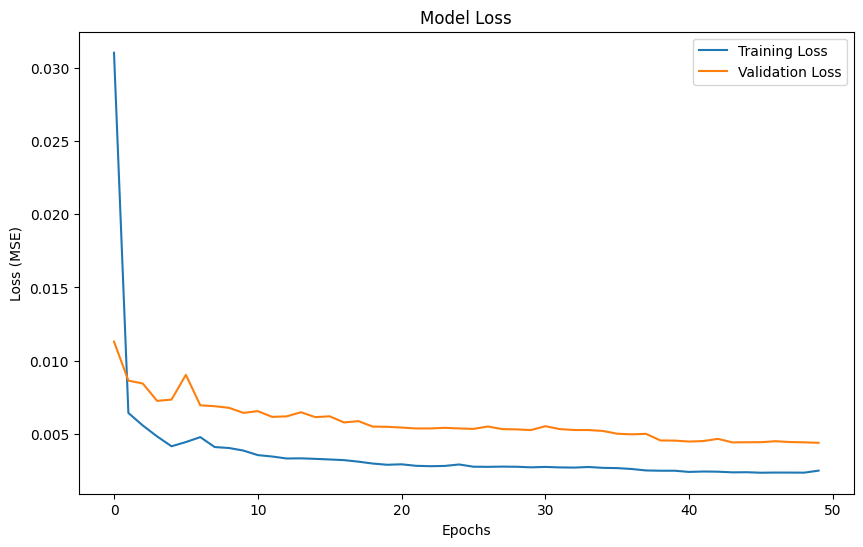

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## 4. Evaluation and Reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


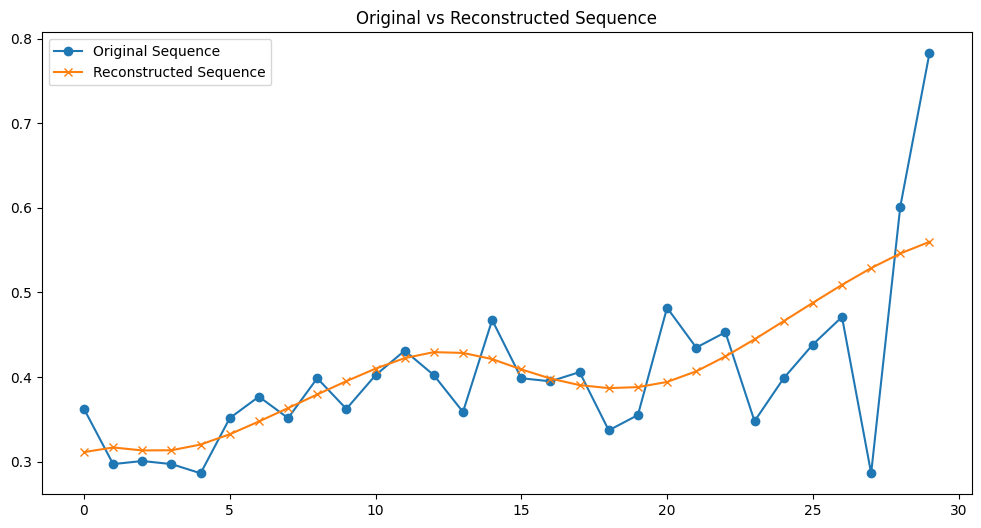

In [35]:
# Predict on test data
X_test_pred = model.predict(X_test)

# Select a random sequence to visualize
idx = 0 # First sequence

plt.figure(figsize=(12, 6))
plt.plot(X_test[idx].flatten(), label='Original Sequence', marker='o')
plt.plot(X_test_pred[idx].flatten(), label='Reconstructed Sequence', marker='x')
plt.title('Original vs Reconstructed Sequence')
plt.legend()
plt.show()

### Insights
- The model learns to compress the 30-day temperature sequence into a latent representation and reconstruct it.
- The reconstruction accuracy depends on the sequence complexity and the model capacity.
- Challenges include handling noise and sudden spikes in the data.